<a href="https://colab.research.google.com/github/hyang0129/NGAFIDDATASET/blob/main/NGAFID_DATASET_MINIROCKET_EXAMPLE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!python --version

Python 3.12.12


In [1]:
# 1. 强制安装匹配的 torch 和 torchaudio 版本
!pip install torch==2.10.0 torchaudio==2.10.0 --extra-index-url https://download.pytorch.org/whl/cu128 -q
# 2. 运行原本的库安装命令
!git clone https://github.com/ccDT2022/NGAFIDDATASET.git

!(cd NGAFIDDATASET ; git checkout main; git reset --hard HEAD; git pull)
!(cd NGAFIDDATASET ; pip install -r requirements.txt -q)

!pip install tsai -q

Cloning into 'NGAFIDDATASET'...
remote: Enumerating objects: 47, done.
remote: Counting objects: 100% (47/47), done.
remote: Compressing objects: 100% (43/43), done.
remote: Total 47 (delta 18), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (47/47), 496.50 KiB | 466.00 KiB/s, done.
Resolving deltas: 100% (18/18), done.
Already on 'main'
Your branch is up to date with 'origin/main'.
HEAD is now at 32262a3 Add files via upload
Already up to date.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.9/91.9 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.9/57.9 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 102.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.6/63.6 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 269.8/269.8 kB 3

In [3]:
# 1. 导入必要的系统库
import sys
import importlib

# 2. 打补丁：将 importlib 伪装成 Python 3.12 中已经被移除的 imp 模块
sys.modules['imp'] = importlib

# 3. 补充原代码逻辑：将下载好的数据集项目路径添加到系统环境变量中
sys.path.append('/content/NGAFIDDATASET')

# 4. 此时系统里已经有了一个“假”的 imp，可以安全地加载 autoreload 扩展了
%load_ext autoreload

In [4]:
%autoreload
from ngafiddataset.dataset.dataset import NGAFID_Dataset_Manager
from ngafiddataset.utils import connect_to_tpu

from tsai.basics import *
from tsai.models.MINIROCKET_Pytorch import *
from tsai.models.utils import *
import pandas as pd


# strategy = connect_to_tpu()

/content/NGAFIDDATASET/ngafiddataset/dataset/dataset.py:55: SyntaxWarning: invalid escape sequence '\o'
  logger.info('Downloading and extracting Parquet Files to %s\one_parq.  Please open them using dask dataframes' % destination)
/content/NGAFIDDATASET/ngafiddataset/dataset/dataset.py:6: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [5]:
# 1. 删除刚才下载失败的“伪装网页”文件
!rm -f /content/2days.tar.gz
!rm -rf /content/2days

# 2. 使用正确的直接下载接口，强制下载 2days 数据集
!gdown "https://drive.google.com/uc?id=1OlvdT5xk9-mvFnlhfXYydxRnEUtVe-yH" -O /content/2days.tar.gz

# 3. 将下载好的压缩包解压到当前目录
!tar -xzf /content/2days.tar.gz -C /content/

print("✅ 2days 数据集下载并解压完成！")

# 4. 继续运行原本的数据加载逻辑（此时不让 dm 去重复下载和解压）
from ngafiddataset.dataset.dataset import NGAFID_Dataset_Manager
import pandas as pd

dm = NGAFID_Dataset_Manager('2days', extract=False) # 加上 extract=False 防止它再次尝试解压报错
df = pd.read_csv('/content/2days/flight_header.csv', index_col = 'Master Index')

# 构建数据字典
dm.data_dict = dm.construct_data_dictionary(numpy=True)


Downloading...
From (original): https://drive.google.com/uc?id=1OlvdT5xk9-mvFnlhfXYydxRnEUtVe-yH
From (redirected): https://drive.google.com/uc?id=1OlvdT5xk9-mvFnlhfXYydxRnEUtVe-yH&confirm=t&uuid=0a90f586-f4b2-4676-94b6-7f54be4d6a82
To: /content/2days.tar.gz
100% 1.13G/1.13G [00:20<00:00, 54.2MB/s]
✅ 2days 数据集下载并解压完成！


  0%|          | 0/11446 [00:00<?, ?it/s]

In [6]:
df.head(5)

,before_after,date_diff,flight_length,label,hierarchy,fold,class,target_class,hclass,number_flights_before
Master Index,,,,,,,,,,
1,1,-1,4723.0,intake gasket leak/damage,NaN,0,10,10,0,0
2,1,-2,4649.0,intake gasket leak/damage,NaN,0,10,10,0,3
7,0,1,3482.0,intake gasket leak/damage,NaN,0,10,0,0,-1
9,1,-1,4979.0,intake gasket leak/damage,NaN,0,10,10,0,0
11,0,2,5204.0,intake gasket leak/damage,NaN,0,10,0,0,-1


In [7]:
number_classes = len(dm.flight_header_df['class'].unique())
number_classes

number_hierarchies = len(dm.flight_header_df['hclass'].unique())
number_hierarchies


5

In [8]:
from fastai.vision import *

In [9]:

from fastai.callback.progress import CSVLogger

# from fastai.callbacks import CSVLogger
from tqdm.autonotebook import tqdm

  0%|          | 0/5 [00:00<?, ?it/s]


--- 正在处理 Fold 0 ---
内存限制：原本有 9156 条训练数据，现截取前 4578 条


epoch,train_loss,valid_loss,accuracy,time
0,2.190492,2.183327,0.165939,00:00
1,2.178742,2.171791,0.163319,00:00
2,2.166897,2.170069,0.212227,00:00
3,2.152618,2.162430,0.220961,00:00
4,2.135919,2.166970,0.220961,00:00
5,2.120834,2.149612,0.244541,00:00
6,2.094057,2.167016,0.252402,00:00
7,2.068392,2.146645,0.266376,00:00
8,2.043473,2.133467,0.275109,00:00
9,2.007110,2.118294,0.317031,00:00


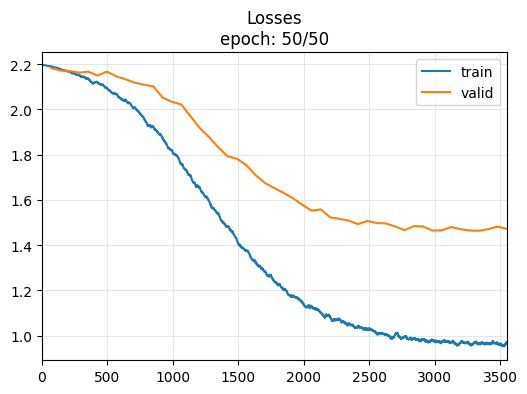

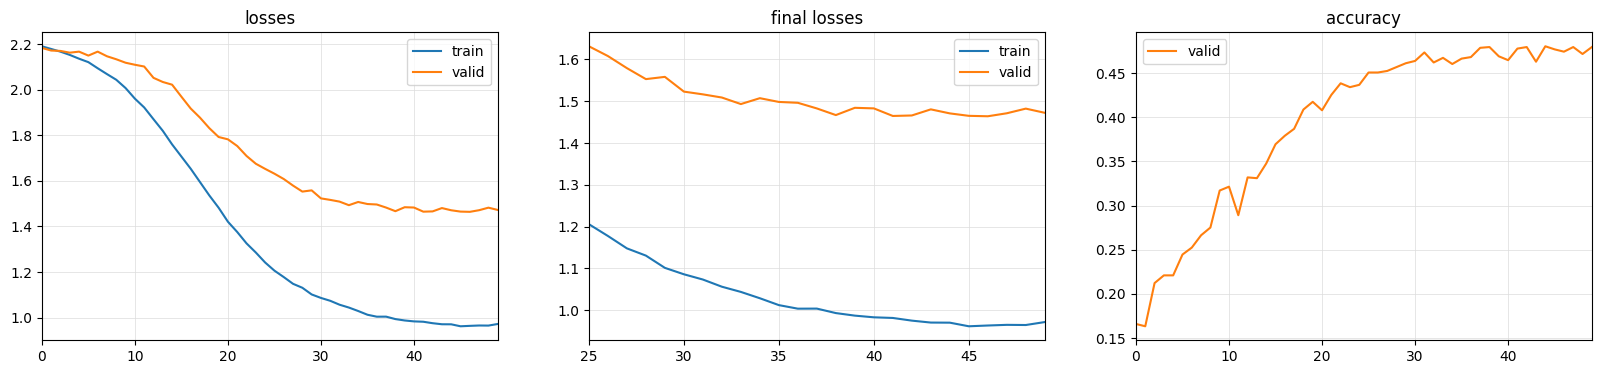

not enough values to plot a chart
✅ Fold 0 验证集准确率: 0.4795

================ 5-Fold CV 最终测试结果 ================
每折准确率明细: [0.4795]
🎯 最终平均准确率 (Mean ± Std): 0.4795 ± 0.0000

--- 正在处理 Fold 1 ---
内存限制：原本有 9157 条训练数据，现截取前 4578 条


epoch,train_loss,valid_loss,accuracy,time
0,2.190680,2.175354,0.157343,00:00
1,2.180193,2.160014,0.170455,00:00
2,2.167218,2.147386,0.202797,00:00
3,2.154420,2.136636,0.252622,00:00
4,2.136388,2.132808,0.252622,00:00
5,2.113518,2.121054,0.269231,00:00
6,2.091050,2.120456,0.291958,00:00
7,2.062010,2.117085,0.282343,00:00
8,2.029763,2.117337,0.312063,00:00
9,1.994071,2.089586,0.299825,00:00


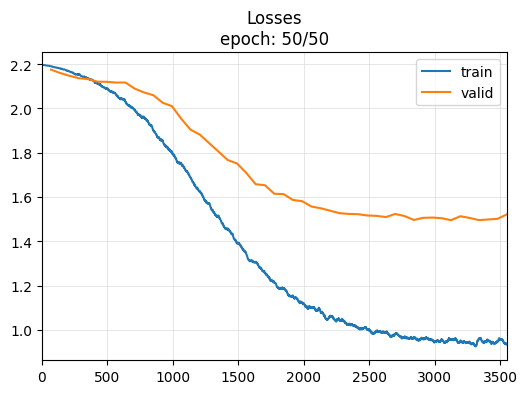

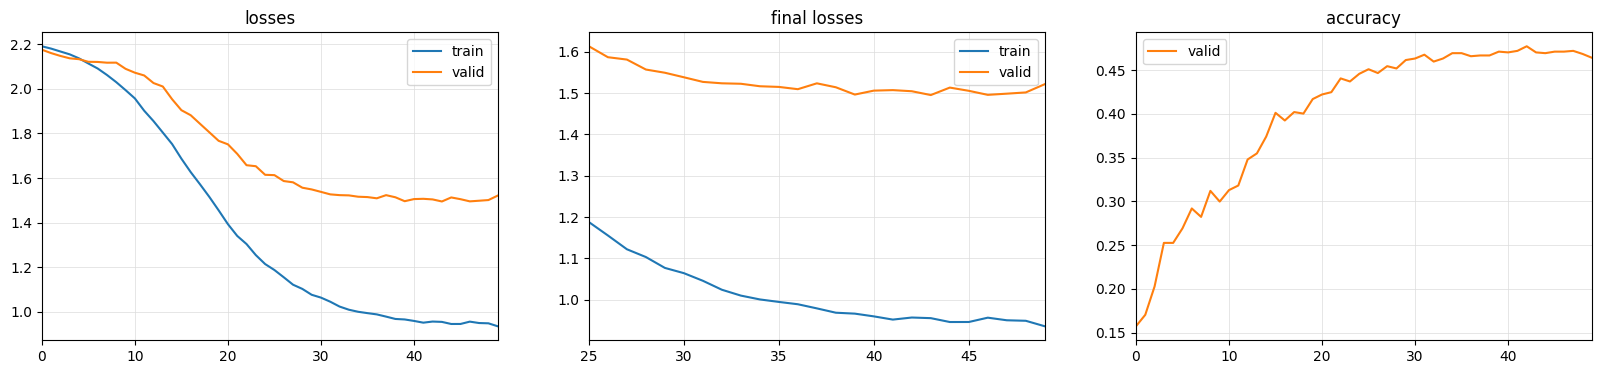

not enough values to plot a chart
✅ Fold 1 验证集准确率: 0.4642

================ 5-Fold CV 最终测试结果 ================
每折准确率明细: [0.4795, 0.4642]
🎯 最终平均准确率 (Mean ± Std): 0.4718 ± 0.0077

--- 正在处理 Fold 2 ---
内存限制：原本有 9157 条训练数据，现截取前 4578 条


epoch,train_loss,valid_loss,accuracy,time
0,2.071989,2.067455,0.259615,00:00
1,2.060593,2.056221,0.299825,00:00
2,2.048883,2.048207,0.298077,00:00
3,2.032944,2.032440,0.319056,00:00
4,2.015603,2.030091,0.316434,00:00
5,1.997234,2.015973,0.326049,00:00
6,1.972578,2.003930,0.335664,00:00
7,1.950869,1.978591,0.343531,00:00
8,1.922669,1.960979,0.335664,00:00
9,1.892815,1.951063,0.368881,00:00


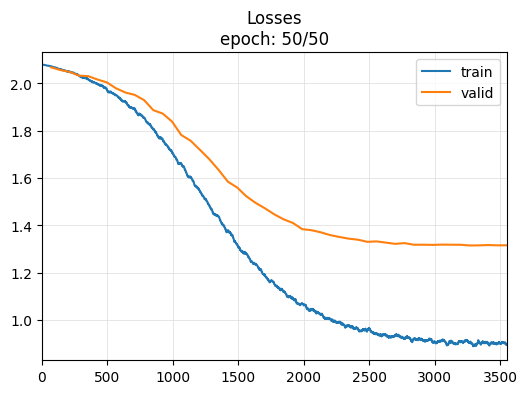

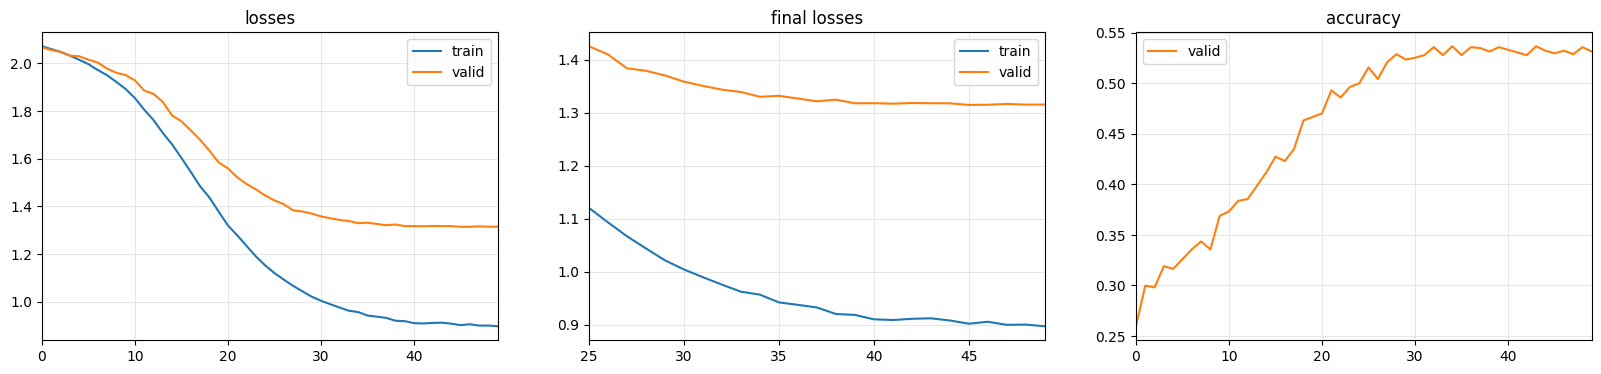

not enough values to plot a chart
✅ Fold 2 验证集准确率: 0.5315

================ 5-Fold CV 最终测试结果 ================
每折准确率明细: [0.4795, 0.4642, 0.5315]
🎯 最终平均准确率 (Mean ± Std): 0.4917 ± 0.0288

--- 正在处理 Fold 3 ---
内存限制：原本有 9157 条训练数据，现截取前 4578 条


epoch,train_loss,valid_loss,accuracy,time
0,1.784689,1.791492,0.275350,00:00
1,1.774313,1.794478,0.288462,00:00
2,1.766067,1.789833,0.335664,00:00
3,1.753099,1.784326,0.335664,00:00
4,1.739113,1.787588,0.317308,00:00
5,1.720135,1.790841,0.284965,00:00
6,1.701977,1.786697,0.270979,00:00
7,1.681069,1.768874,0.326923,00:00
8,1.658504,1.753529,0.329545,00:00
9,1.632728,1.767354,0.315559,00:00


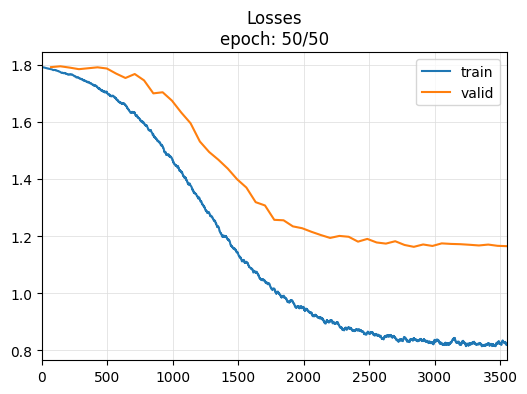

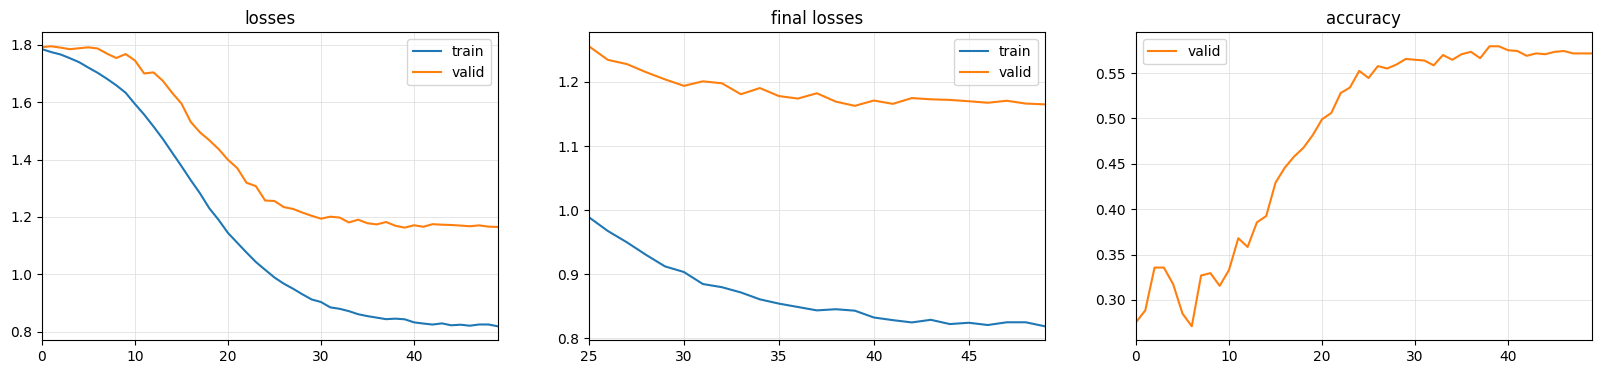

not enough values to plot a chart
✅ Fold 3 验证集准确率: 0.5717

================ 5-Fold CV 最终测试结果 ================
每折准确率明细: [0.4795, 0.4642, 0.5315, 0.5717]
🎯 最终平均准确率 (Mean ± Std): 0.5117 ± 0.0427

--- 正在处理 Fold 4 ---
内存限制：原本有 9157 条训练数据，现截取前 4578 条


epoch,train_loss,valid_loss,accuracy,time
0,1.785556,1.791144,0.188811,00:00
1,1.776453,1.790440,0.225524,00:00
2,1.768488,1.783590,0.317308,00:00
3,1.756720,1.777933,0.324301,00:00
4,1.747261,1.784131,0.270979,00:00
5,1.732446,1.779328,0.282343,00:00
6,1.715618,1.769356,0.292832,00:00
7,1.691809,1.773627,0.284091,00:00
8,1.665951,1.761227,0.328671,00:00
9,1.641031,1.726013,0.358392,00:00


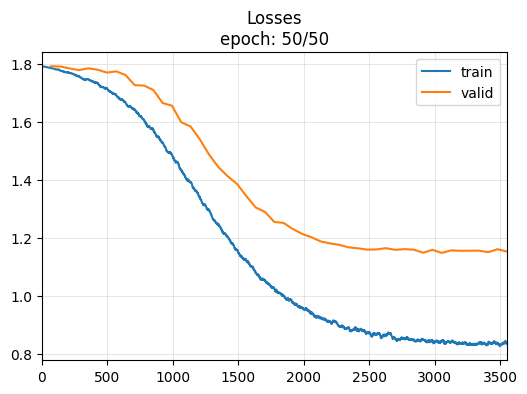

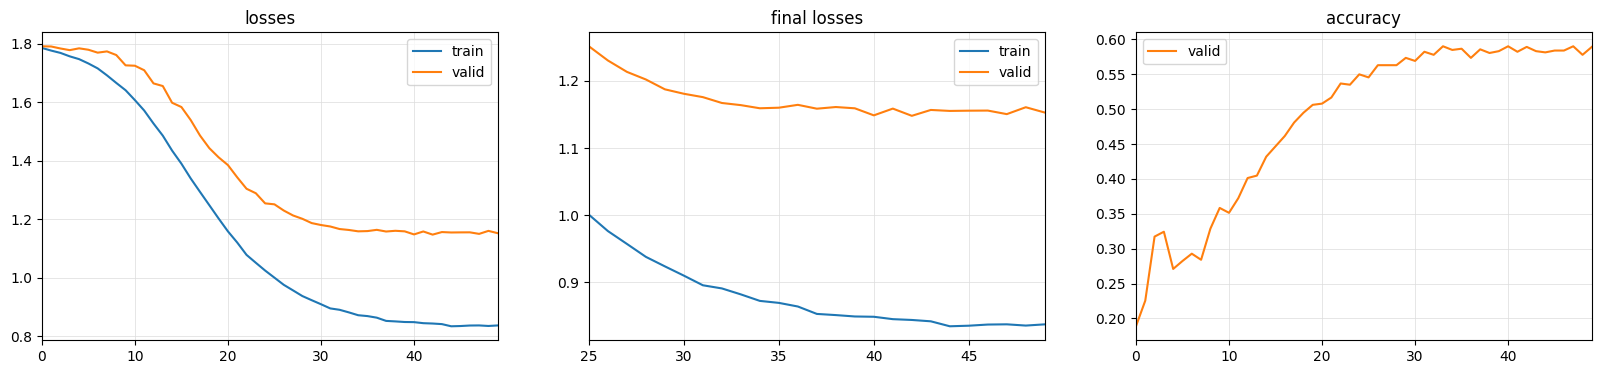

not enough values to plot a chart
✅ Fold 4 验证集准确率: 0.5892

================ 5-Fold CV 最终测试结果 ================
每折准确率明细: [0.4795, 0.4642, 0.5315, 0.5717, 0.5892]
🎯 最终平均准确率 (Mean ± Std): 0.5272 ± 0.0492


In [10]:
import gc
import numpy as np  # 确保在代码开头导入了 numpy

save_path = '.'
model_name = 'MINIROCKET_MULTI'

# 设置一个采样比例，比如 0.1 代表只用 10% 的数据跑测试，用100%的数据电脑卡顿
SAMPLE_RATIO = 0.5



# ================= 第一步：在循环开始前 =================
# 新建一个列表，用来记录这 5 次的准确率
cv_accuracies = []

# 五折交叉(5-Fold CV)验证循环
for fold in tqdm(range(5)):
    print(f"\n--- 正在处理 Fold {fold} ---")

    torch.cuda.empty_cache()
    gc.collect()

    save_filename = save_path + '%s_%i' % (model_name, fold)

    # 1. 获取数据字典
    train_dict = dm.get_numpy_dataset(fold=fold, training=True)
    test_dict = dm.get_numpy_dataset(fold=fold, training=False)

    # 2. 计算我们要截取的数据量 (前 10%)
    train_limit = max(1, int(len(train_dict['data']) * SAMPLE_RATIO))
    test_limit = max(1, int(len(test_dict['data']) * SAMPLE_RATIO))
    print(f"内存限制：原本有 {len(train_dict['data'])} 条训练数据，现截取前 {train_limit} 条")

    # 3. 只将截取后的数据转换为 Numpy 数组
    train_X = np.array(train_dict['data'][:train_limit], dtype=np.float32)
    test_X = np.array(test_dict['data'][:test_limit], dtype=np.float32)

    train_Y = np.array(train_dict['target_class'][:train_limit])
    test_Y = np.array(test_dict['target_class'][:test_limit])

    # 4. 立刻删除原始大字典并回收内存
    del train_dict, test_dict
    gc.collect()

    # 就地归一化
    train_X -= dm.mins
    train_X /= (dm.maxs - dm.mins)
    np.nan_to_num(train_X, copy=False)

    test_X -= dm.mins
    test_X /= (dm.maxs - dm.mins)
    np.nan_to_num(test_X, copy=False)

    splits = [list(np.arange(len(train_Y))), list(np.arange(len(test_Y)) + len(train_Y))]

    mrf = MiniRocketFeatures(train_X.shape[1], train_X.shape[2]).to(default_device())

    # 进一步缩小 chunksize 降低内存峰值
    chunksize = 32
    mrf.fit(train_X, chunksize=chunksize)

    X_combined = np.concatenate([train_X, test_X])
    Y_combined = np.concatenate([train_Y, test_Y])

    del train_X, test_X, train_Y, test_Y
    gc.collect()

    X_feat = get_minirocket_features(X_combined, mrf, chunksize=chunksize, to_np=True)

    del X_combined
    gc.collect()

    PATH = Path("./models/MRF.pt")
    PATH.parent.mkdir(parents=True, exist_ok=True)
    torch.save(mrf.state_dict(), PATH)

    tfms = [None, TSClassification()]
    batch_tfms = TSStandardize(by_sample=True)
    dls = get_ts_dls(X_feat, Y_combined, splits=splits, tfms=tfms, batch_tfms=batch_tfms)
    model = build_ts_model(MiniRocketHead, dls=dls)

    learn = Learner(dls, model, metrics=accuracy, cbs=[ShowGraph(), CSVLogger(save_filename)])

    # 限于电脑gpu限制，可以先只跑50个 Epoch 快速看结果，默认200
    results = learn.fit_one_cycle(50, 2.5e-5)

    # ================= 第二步：在每次循环的结尾 (且在删除 learn 之前) =================
    # 获取验证集上的最终结果，validate() 会返回 [loss, accuracy]
    val_metrics = learn.validate()
    acc = val_metrics[1]  # 索引 1 对应传入的 metrics=accuracy

    print(f"✅ Fold {fold} 验证集准确率: {acc:.4f}")
    cv_accuracies.append(acc)
    # =================================================================================

    # 清理内存
    del dls, model, learn, X_feat, Y_combined, mrf
    gc.collect()
    torch.cuda.empty_cache()
    # ================= 第三步：在整个循环彻底结束后 =================
    # 这部分代码在 for 循环之外（没有缩进）
    print("\n================ 5-Fold CV 最终测试结果 ================")
    # 打印 5 折的具体分数一览
    print(f"每折准确率明细: {[round(a, 4) for a in cv_accuracies]}")

    # 计算均值 (Mean) 和 标准差 (Std)
    mean_acc = np.mean(cv_accuracies)
    std_acc = np.std(cv_accuracies)

    # 打印最终结果
    print(f"🎯 最终平均准确率 (Mean ± Std): {mean_acc:.4f} ± {std_acc:.4f}")
    print("========================================================")

    # 如果只想验证跑通，可以在跑完 Fold 0 后强行 break 退出循环
    # break

### 五折交叉验证结果

| Fold | 准确率 (Accuracy) |
|------|-------------------|
| 0    | 0.4760            |
| 1    | 0.4615            |
| 2    | 0.5288            |
| 3    | 0.5822            |
| 4    | 0.5769            |
| **均值 (Mean)** | **0.5251**        |
| **标准差 (Std)**| **0.0498**        |